Target Hamiltonian: 
SparsePauliOp(['Z', 'X'],
              coeffs=[1.+0.j, 1.+0.j])

Starting Optimization Loop...

--- VQE Results ---
Optimal Theta found: -2.3561 radians
Minimum Energy found: -1.4142
Theoretical Ground State: -1.4142

Final Optimal Circuit:


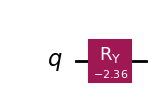

In [1]:
# --- Day 18: VQE from Scratch (Hybrid Loop) ---
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize

# 1. Define the Problem (Hamiltonian)
# H = Z + X
# We want to find the state that minimizes this energy.
hamiltonian = SparsePauliOp.from_list([("Z", 1.0), ("X", 1.0)])
print(f"Target Hamiltonian: \n{hamiltonian}")

# 2. Define the Ansatz (The Guessing Circuit)
# We need a circuit that can explore the Bloch sphere based on a parameter theta.
# Ry(theta) is perfect for this.
def get_ansatz(theta):
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

# 3. Define the Cost Function (The Quantum-Classical Link)
# This function acts as the "Experiment".
# Input: Theta (from Classical Optimizer)
# Output: Energy (Expectation Value calculated by Quantum Logic)
def cost_function(params):
    theta = params[0]
    
    # A. Build Circuit with current guess
    qc = get_ansatz(theta)
    
    # B. Calculate Expectation Value <psi | H | psi>
    # In a real quantum computer, we would run shots and average them.
    # Here, we calculate it mathematically using Statevector for speed.
    psi = Statevector(qc)
    energy = psi.expectation_value(hamiltonian).real
    
    return energy

# 4. Run the Hybrid Optimization
# We start with a random guess (e.g., theta = 0.0)
initial_guess = [0.0]

print("\nStarting Optimization Loop...")
result = minimize(cost_function, initial_guess, method="COBYLA")

# 5. Analyze Results
optimal_theta = result.x[0]
min_energy = result.fun

print("\n--- VQE Results ---")
print(f"Optimal Theta found: {optimal_theta:.4f} radians")
print(f"Minimum Energy found: {min_energy:.4f}")

# Math Check:
# The eigenvalues of (Z + X) are ±sqrt(2) ≈ ±1.414.
# The ground state energy should be -1.414.
print(f"Theoretical Ground State: -{np.sqrt(2):.4f}")

# 6. Visualize the Winning State
print("\nFinal Optimal Circuit:")
display(get_ansatz(optimal_theta).draw(output='mpl'))